In [1]:
import os

os.chdir("../")

## Imports

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib.legend_handler import HandlerTuple
from matplotlib.patches import Ellipse, Patch
from scipy.io import loadmat
from sklearn.calibration import calibration_curve
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, roc_auc_score, roc_curve, silhouette_samples
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.utils import resample
from statannotations.Annotator import Annotator

from src._config import IMG_DIR, MAX_BELIEF_COHORT_A, MAX_BELIEF_COHORT_B, RANDOM_SEED
from src.cluster2 import (
    CLUSTERERS,
    fit_predict,
    fuzzy_fit_predict,
    ablate_k,
    ablate_X,
    ablate_solver,
)
from src.preprocessing import (
    collect_metrics,
    load_behavioral_features,
    sample_behavioral_features,
)

FIG2_DIR = Path(IMG_DIR) / "fig2"
os.makedirs(FIG2_DIR, exist_ok=True)

palette = {
    0: "#de8f05",
    2: "#0173b2",
    1: "#029e73",
}

CLUSTERS = [
    {"label": 2, "name": "Non-aggressive", "annot_xy": (-3, -3.5)},
    {"label": 1, "name": "Proactive", "annot_xy": (2, -3.25)},
    {"label": 0, "name": "Reactive", "annot_xy": (-1.5, 4)},
]

## Data

In [7]:
pred = pd.read_csv("data/cohort_a/predictions.csv", header=None)
actual_vba = pd.read_csv("data/cohort_a/decisions.csv", header=None)
ids = pd.read_csv("data/cohort_a/subject_ids.csv")
outliers = loadmat("data/cohort_a/outliers.mat", squeeze_me=True)["outliers"]

# Align indices (excluding outliers)
pred.index = ids["subject"]
actual_vba.index = ids["subject"]
included = pred.index[~pred.index.isin(outliers)]
pred_clean = pred.loc[included].values
actual_clean = actual_vba.loc[included].values

# Sort by total shocks
sort_order = actual_clean.sum(axis=1).argsort()
actual_sorted = actual_clean[sort_order]
pred_sorted = pred_clean[sort_order]

In [9]:
script = pd.read_excel("data/shared/AggressionScript.xlsx", index_col="Session")
shocked = script.loc["Shocked"].values.astype(int)
shock_trials = np.where(shocked == 1)[0]

wins = script.loc["Win"].values.astype(int)

### Cohort A

In [3]:
# Load raw data
coefs = pd.read_csv("data/cohort_a/coefficients.csv", index_col=0)
print("VBA coefficients (single-point estimate):")
print(coefs.head())
aggro = pd.read_excel("data/cohort_a/aggroPerformance.xlsx", index_col="Subject")
print("Performance:")
print(aggro.head())
beliefs = pd.read_excel("data/cohort_a/beliefs.xlsx", index_col="ID")
if sorted(beliefs.columns) != ["opponent1", "opponent2"]:
    beliefs.rename(columns={k: k[4:] + k[0] for k in beliefs.columns}, inplace=True)
beliefs.drop("opponent3", axis=1, errors="ignore", inplace=True)
print("Opponent beliefs:")
print(beliefs.head())

VBA coefficients (single-point estimate):
           Kr1       Krc        Kp       Kwc
Row                                         
P035  1.322705  2.272587  0.887749 -0.105633
P036  0.409220 -1.830927  0.856839  1.624471
P039  2.147883 -1.102114 -2.232816  0.309552
P041 -0.704294 -0.983443 -2.826260  0.500905
P042 -0.793372  0.147495 -0.700385  1.134931
Performance:
         shock_M_ 1  shock_M_ 2  shock_M_ 3  shock_M_ 4  shock_M_ 5  \
Subject                                                               
P035              0           0           0           1           1   
P036              1           1           1           1           1   
P039              0           0           0           0           0   
P041              0           0           0           0           0   
P042              0           0           1           0           1   

         shock_M_ 6  shock_M_ 7  shock_M_ 8  shock_M_ 9  shock_M_10  ...  \
Subject                                                 

In [4]:
vba_metrics = pd.read_csv("data/cohort_a/fit_metrics.csv", index_col=0)
vba_preds = pd.read_csv("data/cohort_a/predictions.csv", header=None)
vba_actual = pd.read_csv("data/cohort_a/decisions.csv", header=None)
ids = pd.read_csv("data/cohort_a/subject_ids.csv")

vba_preds.index = ids["subject"]
vba_actual.index = ids["subject"]

all_metrics = collect_metrics(vba_metrics, vba_preds, vba_actual)

all_metrics.head()

,R2,accuracy,balanced_accuracy,log_evidence,AUC,Brier
Row,,,,,,
P035,0.151694,0.833333,0.500000,-3476.178261,0.876000,0.115001
P036,0.202331,0.757031,0.708008,-5471.351308,0.791667,0.187659
P039,0.322571,0.869141,0.513409,-3068.142219,0.961538,0.074803
P041,0.000000,1.000000,NaN,-782.871692,0.500000,0.001554
P042,0.080530,0.713281,0.489435,-4958.373115,0.715909,0.179249


In [5]:
bma_a = load_behavioral_features(
    coefs,
    all_metrics,
    aggro,
    beliefs,
)

print(bma_a.shape)

bma_a.head()

(114, 15)


,Kr1,Krc,Kp,Kwc,R2,accuracy,balanced_accuracy,log_evidence,AUC,Brier,shock_opp1,shock_opp2,first_shock,belief_opp1,belief_opp2
Row,,,,,,,,,,,,,,,
P035,1.322705,2.272587,0.887749,-0.105633,0.151694,0.833333,0.500000,-3476.178261,0.876000,0.115001,10.0,15.0,3.0,5.000000,3.000000
P036,0.409220,-1.830927,0.856839,1.624471,0.202331,0.757031,0.708008,-5471.351308,0.791667,0.187659,8.0,10.0,0.0,4.333963,4.698228
P039,2.147883,-1.102114,-2.232816,0.309552,0.322571,0.869141,0.513409,-3068.142219,0.961538,0.074803,1.0,3.0,11.0,7.000000,5.000000
P042,-0.793372,0.147495,-0.700385,1.134931,0.080530,0.713281,0.489435,-4958.373115,0.715909,0.179249,2.0,6.0,2.0,4.000000,5.000000
P043,-0.704294,-0.983443,-2.826260,0.500905,0.000000,1.000000,0.357809,-782.871692,0.500000,0.001554,0.0,0.0,30.0,5.000000,0.000000


### Cohort B

In [6]:
coefs_b = pd.read_csv("data/cohort_b/coefficients.csv", index_col=0)
print("VBA coefficients (single-point estimate; cohort B):")
print(coefs_b.head())
aggro_b = pd.read_excel("data/cohort_b/aggroPerformance.xlsx", index_col="Subject")
print("Performance (cohort B):")
print(aggro_b.head())
beliefs_b = pd.read_excel("data/cohort_b/beliefs.xlsx", index_col="ID")
beliefs_b = beliefs_b * (MAX_BELIEF_COHORT_A / MAX_BELIEF_COHORT_B)
print("Opponent beliefs (cohort B):")
print(f"Shape: {beliefs_b.shape}")
print(beliefs_b.head())

VBA coefficients (single-point estimate; cohort B):
            Kr1       Krc        Kp       Kwc
Row                                          
BF042 -0.566837  1.311892 -1.126599 -0.358198
BF055  0.446400 -0.963399  0.389564  0.147150
BF060  0.846845  1.040426  2.024652  0.614868
BF065 -1.006059 -1.155588  0.547222  0.203727
BF069  1.413274  1.507436 -0.658041  0.221011
Performance (cohort B):
         shock_M_ 1  shock_M_ 2  shock_M_ 3  shock_M_ 4  shock_M_ 5  \
Subject                                                               
BF042             0           0           0           0           0   
BF055             1           1           1           1           1   
BF065             1           1           0           1           1   
BF069             1           1           0           0           0   
BF087             0           0           0           0           0   

         shock_M_ 6  shock_M_ 7  shock_M_ 8  shock_M_ 9  shock_M_10  ...  \
Subject                     

In [7]:
vba_metrics_b = pd.read_csv("data/cohort_b/fit_metrics.csv", index_col=0)
vba_preds_b = pd.read_csv("data/cohort_b/predictions.csv", header=None)
vba_actual_b = pd.read_csv("data/cohort_b/decisions.csv", header=None)
ids_b = pd.read_csv("data/cohort_b/subject_ids.csv")

vba_preds_b.index = ids_b["subject"]
vba_actual_b.index = ids_b["subject"]

all_metrics_b = collect_metrics(vba_metrics_b, vba_preds_b, vba_actual_b)
print(all_metrics_b.shape)
all_metrics_b.head()

(42, 6)


,R2,accuracy,balanced_accuracy,log_evidence,AUC,Brier
Row,,,,,,
BF042,0.077620,0.740365,0.513184,-5200.962486,0.664773,0.179840
BF055,0.042331,0.603365,0.544792,-5332.044788,0.675758,0.233353
BF060,0.067995,0.928571,0.500000,-2226.323896,0.961538,0.061233
BF065,0.159349,0.666406,0.666406,-5690.286390,0.815556,0.209618
BF069,0.274577,0.720770,0.715569,-4978.783961,0.878571,0.180146


In [8]:
bma_b = load_behavioral_features(
    coefs_b, all_metrics_b, aggro_b, beliefs_b, remove_outliers=True
)

print(bma_b.shape)

bma_b.head()

(37, 15)


,Kr1,Krc,Kp,Kwc,R2,accuracy,balanced_accuracy,log_evidence,AUC,Brier,shock_opp1,shock_opp2,first_shock,belief_opp1,belief_opp2
Row,,,,,,,,,,,,,,,
BF042,-0.566837,1.311892,-1.126599,-0.358198,0.077620,0.740365,0.513184,-5200.962486,0.664773,0.179840,4.0,4.0,8.0,6.000000,2.000000
BF055,0.446400,-0.963399,0.389564,0.147150,0.042331,0.603365,0.544792,-5332.044788,0.675758,0.233353,9.0,6.0,0.0,10.000000,10.000000
BF060,0.846845,1.040426,2.024652,0.614868,0.067995,0.928571,0.500000,-2226.323896,0.961538,0.061233,10.0,10.0,30.0,0.426593,5.787803
BF065,-1.006059,-1.155588,0.547222,0.203727,0.159349,0.666406,0.666406,-5690.286390,0.815556,0.209618,10.0,5.0,0.0,8.000000,4.000000
BF069,1.413274,1.507436,-0.658041,0.221011,0.274577,0.720770,0.715569,-4978.783961,0.878571,0.180146,6.0,8.0,0.0,0.000000,0.000000


In [9]:
scaler = StandardScaler()
cols_to_drop = ["Brier", "AUC", "accuracy", "balanced_accuracy", "log_evidence"]
Xa = bma_a.drop(columns=cols_to_drop)
Xb = bma_b.drop(columns=cols_to_drop)
print(f"{Xa.shape[1]} columns used: {Xa.columns.tolist()}")
Xa_scaled = scaler.fit_transform(Xa)
Xb_scaled = scaler.transform(Xb)

10 columns used: ['Kr1', 'Krc', 'Kp', 'Kwc', 'R2', 'shock_opp1', 'shock_opp2', 'first_shock', 'belief_opp1', 'belief_opp2']


## Fig. 2a: observed vs. predicted decisions

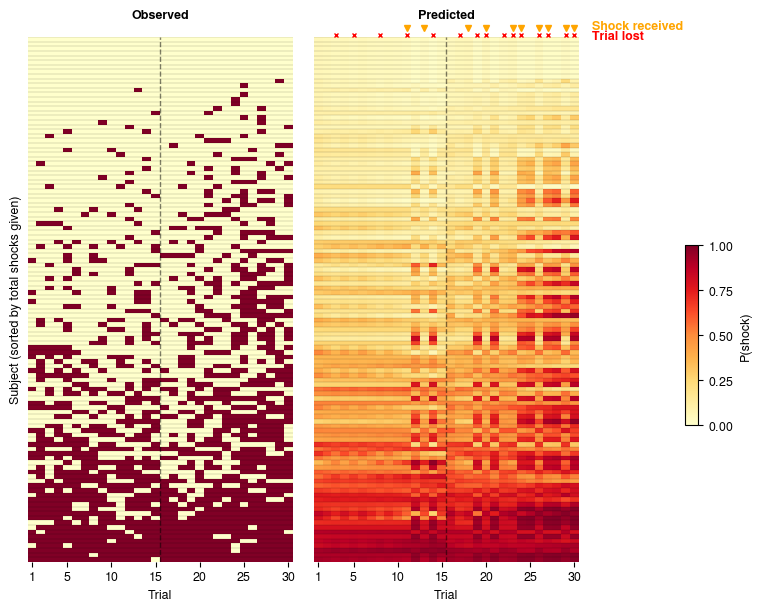

In [10]:
# Plot
with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(7, 6),
        gridspec_kw={"width_ratios": [1, 1, 0.05], "wspace": 0.08},
        layout="constrained",
    )

    cmap = "YlOrRd"

    sns.heatmap(
        actual_sorted,
        cmap=cmap,
        vmin=0,
        vmax=1,
        cbar=False,
        ax=axes[0],
    )
    axes[0].set_title("Observed", y=1.02, fontweight="bold")
    axes[0].set_ylabel("Subject (sorted by total shocks given)")
    sns.heatmap(
        pred_sorted,
        cmap=cmap,
        vmin=0,
        vmax=1,
        cbar=False,
        ax=axes[1],
    )
    axes[1].set_title("Predicted", y=1.02, fontweight="bold")
    ticks = [1, 5, 10, 15, 20, 25, 30]
    for ax in axes[:-1]:
        ax.set_xticks([t - 0.5 for t in ticks])
        ax.set_xticklabels(ticks)
        ax.set_xlabel("Trial")
        ax.axvline(x=15, color="black", linestyle="--", linewidth=1, alpha=0.5)
        ax.set_yticks([])
        for i in range(len(actual_sorted)):
            ax.axhline(y=i, color="k", linewidth=0.1)
    for t in range(30):
        if shocked[t]:
            ax.plot(t + 0.5, -2.0, marker="v", color="orange", markersize=4, clip_on=False)
        if not wins[t]:
            ax.plot(t + 0.5, -0.5, marker="x", color="red",
                markersize=3, clip_on=False, markeredgewidth=1)
    axes[1].text(
        31.5, -0.25, "Trial lost", color="red", va="center", fontweight="bold"
    )
    axes[1].text(31.5, -2.25, "Shock received", color="orange", va="center", fontweight="bold")

    fig.colorbar(axes[1].collections[0], cax=axes[2], label="P(shock)")
    axes[2].set_yticks([0, 0.25, 0.5, 0.75, 1])
    axes[2].set_position(
        [axes[2].get_position().x0, 0.3, axes[2].get_position().width, 0.3]
    )
    plt.savefig(FIG2_DIR / "heatmaps.png", dpi=300, bbox_inches="tight")
    plt.savefig(FIG2_DIR / "heatmaps.pdf", bbox_inches="tight")
    plt.show()

### Supplementary Fig. 3: Variational Bayesian model performance

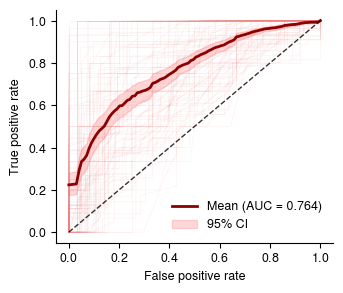

In [63]:
with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, ax = plt.subplots(figsize=(3.5, 3))

    mean_fpr = np.linspace(0, 1, 100)
    tprs = []
    aucs = []

    # Individual ROCs
    for i in range(len(pred_clean)):
        y_true = actual_clean[i]
        y_pred = pred_clean[i]
        if len(np.unique(y_true)) < 2:
            continue
        fpr, tpr, _ = roc_curve(y_true, y_pred)
        aucs.append(roc_auc_score(y_true, y_pred))
        ax.plot(fpr, tpr, color="lightcoral", alpha=0.1, linewidth=0.5)
        # Interpolate to common FPR grid for averaging
        tprs.append(np.interp(mean_fpr, fpr, tpr))

    # Mean ROC
    mean_tpr = np.mean(tprs, axis=0)
    mean_auc = roc_auc_score(
        actual_clean.flatten(), pred_clean.flatten()
    )  # or use per-subject mean
    ax.plot(
        mean_fpr,
        mean_tpr,
        color="darkred",
        linewidth=2,
        label=f"Mean (AUC = {np.mean(aucs):.3f})",
    )

    # 0.5 line
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.8)

    # Bootstrap confidence intervals for mean AUC
    n_bootstrap = 1000
    tprs_array = np.array(tprs)  # (n_subjects, 100)

    boot_means = []
    for _ in range(n_bootstrap):
        idx = resample(np.arange(len(tprs_array)), replace=True)
        boot_means.append(tprs_array[idx].mean(axis=0))

    boot_means = np.array(boot_means)
    tpr_lower = np.percentile(boot_means, 2.5, axis=0)
    tpr_upper = np.percentile(boot_means, 97.5, axis=0)

    ax.fill_between(
        mean_fpr, tpr_lower, tpr_upper, color="red", alpha=0.15, label="95% CI"
    )

    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.legend()
    plt.savefig(FIG2_DIR / "roc_curve.pdf", bbox_inches="tight")
    plt.savefig(FIG2_DIR / "roc_curve.png", dpi=300, bbox_inches="tight")
    plt.show()

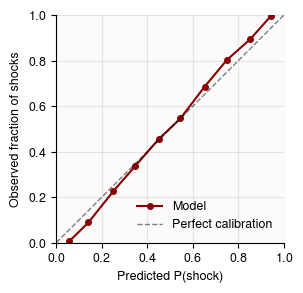

In [65]:
y_true = actual_clean.flatten()
y_pred = pred_clean.flatten()

# Remove NaN if any
mask = ~np.isnan(y_pred) & ~np.isnan(y_true)

fraction_pos, mean_predicted = calibration_curve(y_true[mask], y_pred[mask], n_bins=10)

with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, ax = plt.subplots(figsize=(3.5, 3))
    ax.plot(
        mean_predicted,
        fraction_pos,
        "o-",
        color="darkred",
        markersize=4,
        linewidth=1.5,
        label="Model",
    )
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Perfect calibration")
    ax.fill_between(
        [0, 1],
        [0, 0],
        [1, 1],
        where=[True, True],
        alpha=0.03,
        color="gray",
    )
    ax.set_xlabel("Predicted P(shock)")
    ax.set_ylabel("Observed fraction of shocks")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)
    plt.savefig(FIG2_DIR / "calibration.pdf", bbox_inches="tight")
    plt.savefig(FIG2_DIR / "calibration.png", dpi=300, bbox_inches="tight")
    plt.show()

### Supplementary Fig. 4

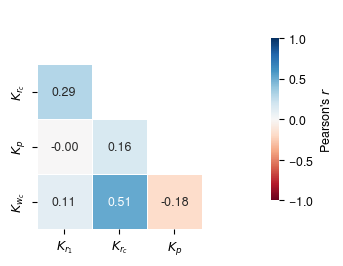

[[ 1.     0.291 -0.001  0.106]
 [ 0.291  1.     0.163  0.509]
 [-0.001  0.163  1.    -0.18 ]
 [ 0.106  0.509 -0.18   1.   ]]


In [94]:
corr_preds = loadmat("data/cohort_a/corr_preds.mat")[
    "corr_preds"
]  # (n_simulations, 4, 4)

# Average across simulations
corr_mean = corr_preds.mean(axis=0)
mask = np.triu(np.ones(corr_mean.shape), k=0).astype(bool)
labels = [r"$K_{r_1}$", r"$K_{r_c}$", r"$K_p$", r"$K_{w_c}$"]

# Annotation: mean values as text
annot = np.array([[f"{corr_mean[i, j]:.2f}" for j in range(4)] for i in range(4)])

with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, ax = plt.subplots(figsize=(3.5, 3))
    sns.heatmap(
        corr_mean,
        mask=mask,
        annot=annot,
        fmt="",
        cmap="RdBu",
        vmin=-1,
        vmax=1,
        square=True,
        xticklabels=labels,
        yticklabels=labels,
        cbar_kws={"label": "Pearson's $r$", "shrink": 0.6},
        linewidths=0.5,
        linecolor="white",
        ax=ax,
    )
    cbar = ax.collections[0].colorbar
    cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
    ax.set_yticks(ax.get_yticks()[1:])
    ax.set_xticks(ax.get_xticks()[:-1])
    # ax.set_title("Model parameter correlations\n(simulation-recovery)", fontweight="bold")

    plt.savefig(FIG2_DIR / "corr_matrix.pdf", bbox_inches="tight")
    plt.savefig(FIG2_DIR / "corr_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()

# print(f"Correlation matrix (mean across {n_subjects} subjects):")
print(np.round(corr_mean, 3))

<>:21: SyntaxWarning: invalid escape sequence '\S'
<>:21: SyntaxWarning: invalid escape sequence '\S'
/tmp/ipykernel_3563332/3624574787.py:21: SyntaxWarning: invalid escape sequence '\S'
  ax.set_xlabel("Cond($\Sigma$)")


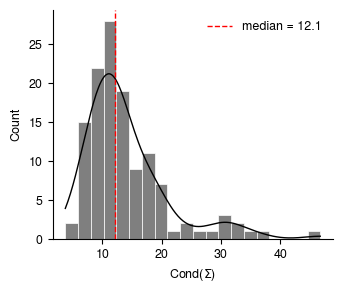

Condition number: median=12.1, min=3.8, max=46.7
All full rank: True


In [95]:
sim_rec = loadmat("data/cohort_a/cov_stats.mat", squeeze_me=True)
cov_stats = sim_rec["cov_stats"]  # (126, 2): [determinant, condition_number]

cond_numbers = cov_stats[:, 1]
determinants = cov_stats[:, 0]
ranks = (determinants > 1e-10).astype(int) * 4  # full rank if det > 0

with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, ax = plt.subplots(1, 1, figsize=(3.5, 3))

    # S1a: Condition numbers
    sns.histplot(
        cond_numbers,
        bins=20,
        color="k",
        edgecolor="white",
        linewidth=0.5,
        kde=True,
        ax=ax,
    )
    ax.set_xlabel("Cond($\Sigma$)")
    # axes[0].hist(cond_numbers, bins=20, color="k", edgecolor="white", linewidth=0.5)
    ax.axvline(
        np.median(cond_numbers),
        color="red",
        linestyle="--",
        label=f"median = {np.median(cond_numbers):.1f}",
    )
    ax.legend(frameon=False)

    fig.tight_layout()
    fig.savefig(FIG2_DIR / "identifiability.pdf", bbox_inches="tight")
    fig.savefig(FIG2_DIR / "identifiability.png", dpi=300, bbox_inches="tight")
    plt.show()

print(
    f"Condition number: median={np.median(cond_numbers):.1f}, "
    f"min={cond_numbers.min():.1f}, max={cond_numbers.max():.1f}"
)
print(f"All full rank: {(ranks == 4).all()}")

## Fig. 2b: PCA projection with clusters

In [25]:
# Cluster with single-point estimates
k = 3
resa = fit_predict(X=Xa_scaled, solver="k-means", k=k, random_state=RANDOM_SEED)
resb_labels = resa.clusterer.predict(Xb_scaled)

In [27]:
post_a = loadmat("data/cohort_a/vba_posteriors.mat")
coefs_mu_a = post_a["mu_all"]
coefs_sigma_a = post_a["sigma_all"]

post_b = loadmat("data/cohort_b/vba_posteriors.mat")
coefs_mu_b = post_b["mu_all"]
coefs_sigma_b = post_b["sigma_all"]

n_samples = 1000

coef_cols = coefs.columns

iterator_a = sample_behavioral_features(
    coefs_mu=coefs_mu_a,
    coefs_sigma=coefs_sigma_a,
    metrics=all_metrics.drop(columns=cols_to_drop),
    aggro=aggro,
    beliefs=beliefs,
    n_samples=n_samples,
)

iterator_b = sample_behavioral_features(
    coefs_mu=coefs_mu_b,
    coefs_sigma=coefs_sigma_b,
    metrics=all_metrics_b.drop(columns=cols_to_drop),
    aggro=aggro_b,
    beliefs=beliefs_b,
    n_samples=n_samples,
    remove_outliers=True,
)

# Cluster with posterior samples
from src.cluster2 import FuzzyClusterResult
res = np.load("data/processed/mc_consensus_k-means_3.npz", allow_pickle=True)
res_kmeans3 = FuzzyClusterResult(
    consensus_a=res["consensus_a"],
    consensus_b=res["consensus_b"],
    stability_a=res["stability_a"],
    stability_b=res["stability_b"],
    label_counts_a=res["label_counts_a"],
    label_counts_b=res["label_counts_b"],
    scaler_means=res["scaler_means"],
    scaler_scales=res["scaler_scales"],
    n_samples=n_samples,
)
# res_kmeans3 = fuzzy_fit_predict(
#     iterator_a=iterator_a,
#     iterator_b=iterator_b,
#     solver="k-means",
#     k=k,
#     random_state=RANDOM_SEED,
#     n_a=len(bma_a),
#     n_b=len(bma_b),
#     ref_labels=resa.labels,
#     n_samples=n_samples,
# )

# np.savez_compressed(
#     "data/processed/mc_consensus_k-means_3.npz",
#     consensus_a=res_kmeans3.consensus_a,
#     consensus_b=res_kmeans3.consensus_b,
#     stability_a=res_kmeans3.stability_a,
#     stability_b=res_kmeans3.stability_b,
#     label_counts_a=res_kmeans3.label_counts_a,
#     label_counts_b=res_kmeans3.label_counts_b,
#     scaler_means=res_kmeans3.scaler_means,
#     scaler_scales=res_kmeans3.scaler_scales,
# )

print(f"Stability (cohort A): {res_kmeans3.stability_a:.3f}")
print(f"Stability (cohort B): {res_kmeans3.stability_b:.3f}")
print(
    "ARI (consensus vs deterministic):",
    adjusted_rand_score(resa.labels, res_kmeans3.consensus_a),
)
print("Cohort B ARI:", adjusted_rand_score(resb_labels, res_kmeans3.consensus_b))

Stability (cohort A): 0.939
Stability (cohort B): 0.945
ARI (consensus vs deterministic): 0.9003208181726069
Cohort B ARI: 0.740486183487789


In [29]:
label_counts_a = res_kmeans3.label_counts_a
changed = res_kmeans3.consensus_a != resa.labels
print(f"Subjects changed: {changed.sum()}/{len(res_kmeans3.consensus_a)}")
for i in np.where(changed)[0]:
    print(
        f"  {bma_a.index[i]}: {resa.labels[i]} → {res_kmeans3.consensus_a[i]} (modal prob: {label_counts_a[i].max() / n_samples:.2f})"
    )

Subjects changed: 4/114
  P042: 2 → 1 (modal prob: 0.53)
  P143: 2 → 0 (modal prob: 0.51)
  P166: 1 → 0 (modal prob: 0.71)
  P174: 1 → 0 (modal prob: 0.53)


In [32]:
# Assign labels
cluster_names = {cl["label"]: cl["name"] for cl in CLUSTERS}

Xa["label"] = res_kmeans3.consensus_a  # resa.labels
Xa["Cluster"] = Xa["label"].map(cluster_names)
Xb["label"] = res_kmeans3.consensus_b  # resb_labels
Xb["Cluster"] = Xb["label"].map(cluster_names)

In [36]:
# PCA on standardized features
pca = PCA(n_components=2, random_state=RANDOM_SEED)
Xa_pca = pca.fit_transform(Xa_scaled)
Xb_pca = pca.transform(Xb_scaled)
Xa[["PC1", "PC2"]] = Xa_pca
Xb[["PC1", "PC2"]] = Xb_pca

# Xa.to_csv("data/processed/behav_Xa.csv")
# Xb.to_csv("data/processed/behav_Xb.csv")

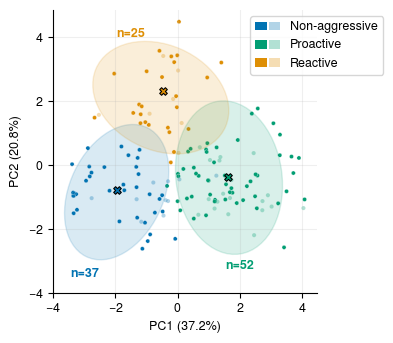

Total variance explained (2D): 58.0%


In [38]:
def confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    cov = np.cov(x, y)
    vals, vecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(vecs[1, 1], vecs[0, 1]))
    w, h = 2 * n_std * np.sqrt(vals)
    ax.add_patch(Ellipse((x.mean(), y.mean()), w, h, angle=angle, **kwargs))


with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, ax = plt.subplots(figsize=(4.0, 3.5))

    plot_data = {
        "x": "PC1",
        "y": "PC2",
        "hue": "label",
        "palette": palette,
    }

    sns.scatterplot(**plot_data, data=Xa, ax=ax, legend=False)
    sns.scatterplot(**plot_data, data=Xb, alpha=0.3, ax=ax, legend=False)

    centroids_pca = pca.transform(resa.clusterer.cluster_centers_)

    for cl in CLUSTERS:
        c = cl["label"]
        mask = Xa["label"] == c

        confidence_ellipse(
            Xa.loc[mask, "PC1"].values,
            Xa.loc[mask, "PC2"].values,
            ax,
            n_std=2.0,
            facecolor=palette[c],
            alpha=0.15,
            edgecolor=palette[c],
            linewidth=1,
        )

        ax.annotate(
            f"n={mask.sum()}",
            xy=cl["annot_xy"],
            fontweight="bold",
            ha="center",
            color=palette[c],
        )

        ax.scatter(
            centroids_pca[int(c), 0],
            centroids_pca[int(c), 1],
            marker="X",
            s=30,
            color=palette[c],
            edgecolors="black",
            linewidths=0.8,
            zorder=5,
        )

    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")

    handles = [
        (
            Patch(facecolor=palette[cl["label"]]),
            Patch(facecolor=palette[cl["label"]], alpha=0.3),
        )
        for cl in CLUSTERS
    ]
    ax.legend(
        handles,
        [cl["name"] for cl in CLUSTERS],
        handler_map={tuple: HandlerTuple(ndivide=None, pad=0.15)},
        loc="upper center",
        bbox_to_anchor=(1.0, 1.0),
        frameon=True,
    )
    ax.grid(alpha=0.2)

    lim = 4
    ticks = np.linspace(-lim, lim, 5)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    plt.savefig(FIG2_DIR / "pca_clusters.pdf", bbox_inches="tight")
    plt.savefig(FIG2_DIR / "pca_clusters.png", dpi=300, bbox_inches="tight")
    plt.show()

print(f"Total variance explained (2D): {pca.explained_variance_ratio_.sum():.1%}")

### Supplementary Table 3

In [ ]:
solvers = list(CLUSTERERS.keys())

all_res = {}

for solver in solvers:
    print(f"Running solver: {solver}")
    iterator_a = sample_behavioral_features(
        coefs_mu=coefs_mu_a,
        coefs_sigma=coefs_sigma_a,
        metrics=all_metrics.drop(columns=cols_to_drop),
        aggro=aggro,
        beliefs=beliefs,
        n_samples=n_samples,
    )

    iterator_b = sample_behavioral_features(
        coefs_mu=coefs_mu_b,
        coefs_sigma=coefs_sigma_b,
        metrics=all_metrics_b.drop(columns=cols_to_drop),
        aggro=aggro_b,
        beliefs=beliefs_b,
        n_samples=n_samples,
        remove_outliers=False,
    )
    if solver == "k-means":
        all_res[solver] = res_kmeans3
    else:
        all_res[solver] = fuzzy_fit_predict(
            iterator_a=iterator_a,
            iterator_b=iterator_b,
            solver=solver,
            k=k,
            random_state=RANDOM_SEED,
            n_a=len(bma_a),
            n_b=len(bma_b),
            ref_labels=resa.labels,
            n_samples=n_samples,
        )

100%|█████████▉| 999/1000 [17:36<00:01,  1.06s/it]


Running solver: k-means
Running solver: k-medoids


100%|█████████▉| 999/1000 [01:44<00:00,  9.61it/s]


Running solver: gmm


100%|██████████| 1000/1000 [02:11<00:00,  7.63it/s]


In [67]:
rows = []
for solver, res in all_res.items():
    rows.append(
        {
            "solver": solver,
            "stability_a": res.stability_a,
            "stability_b": res.stability_b,
            "ARI_with_kmeans": adjusted_rand_score(
                all_res["k-means"].consensus_a, res.consensus_a
            ),
        }
    )
sens_solver = pd.DataFrame(rows).set_index("solver").sort_values(by="stability_a", ascending=False)
print(sens_solver.to_markdown())

| solver    |   stability_a |   stability_b |   ARI_with_kmeans |
|:----------|--------------:|--------------:|------------------:|
| k-means   |      0.938746 |      0.945054 |          1        |
| gmm       |      0.890386 |      0.896081 |          0.637374 |
| k-medoids |      0.726632 |      0.752892 |          0.866646 |


### Supplementary Table 8

In [83]:
def cov_ari(results):
    ari_matrix = pd.DataFrame(
        np.zeros((len(results), len(results))),
        index=results.index,
        columns=results.index,
    )
    for i in range(len(results)):
        for j in range(i + 1, len(results)):
            ari = adjusted_rand_score(
                results.iloc[i]["labels"], results.iloc[j]["labels"]
            )
            ari_matrix.iloc[i, j] = ari
            ari_matrix.iloc[j, i] = ari
            ari_matrix.iloc[i, i] = 1.0
    return ari_matrix

metric_cols = ["R2", "Brier", "AUC", "balanced_accuracy", "accuracy", "log_evidence", "none"]

Xs = {}
for metric in metric_cols:
    if metric == "none":
        X = bma_a.drop(columns=list(set(metric_cols) - {"none"}))
    else:
        X = bma_a.drop(columns=list(set(metric_cols) - {metric, "none"}))
    X_scaled = StandardScaler().fit_transform(X)
    Xs[metric] = X_scaled

sens_X = ablate_X(Xs, solver="k-means", k=k, random_state=RANDOM_SEED)
print(
    sens_X.drop(["labels", "sizes", "clusterer"], axis=1)
    .sort_values(by="silhouette", ascending=False)
    .round(3)
    .to_markdown()
)

|                   |   silhouette |
|:------------------|-------------:|
| R2                |        0.236 |
| balanced_accuracy |        0.229 |
| AUC               |        0.202 |
| none              |        0.194 |
| accuracy          |        0.193 |
| Brier             |        0.19  |
| log_evidence      |        0.184 |


In [86]:
print(cov_ari(sens_X).round(3).to_markdown())

|                   |    R2 |   Brier |   AUC |   balanced_accuracy |   accuracy |   log_evidence |   none |
|:------------------|------:|--------:|------:|--------------------:|-----------:|---------------:|-------:|
| R2                | 1     |   0.325 | 0.581 |               0.824 |      0.716 |          0.504 |  0.781 |
| Brier             | 0.325 |   1     | 0.319 |               0.289 |      0.314 |          0.383 |  0.312 |
| AUC               | 0.581 |   0.319 | 1     |               0.541 |      0.595 |          0.399 |  0.594 |
| balanced_accuracy | 0.824 |   0.289 | 0.541 |               1     |      0.636 |          0.515 |  0.7   |
| accuracy          | 0.716 |   0.314 | 0.595 |               0.636 |      1     |          0.539 |  0.763 |
| log_evidence      | 0.504 |   0.383 | 0.399 |               0.515 |      0.539 |          1     |  0.606 |
| none              | 0.781 |   0.312 | 0.594 |               0.7   |      0.763 |          0.606 |  0     |


### Supplementary Fig. 5

In [87]:
sens_k = ablate_k(
    Xa_scaled, solver="k-means", k_range=range(2, 11), random_state=RANDOM_SEED
)
print(sens_k[["silhouette", "gap", "gap_diff"]].to_markdown())

|    |   silhouette |      gap |   gap_diff |
|---:|-------------:|---------:|-----------:|
|  2 |     0.221769 |  77.7775 |  -14.6019  |
|  3 |     0.23588  | 114.578  |    3.51996 |
|  4 |     0.211815 | 131.946  |   12.2697  |
|  5 |     0.208056 | 140.777  |   25.715   |
|  6 |     0.179328 | 134.784  |   23.1064  |
|  7 |     0.201257 | 131.468  |   14.5529  |
|  8 |     0.189052 | 134.72   |   17.7841  |
|  9 |     0.202641 | 135.016  |   18.1735  |
| 10 |     0.189545 | 133.451  |  nan       |


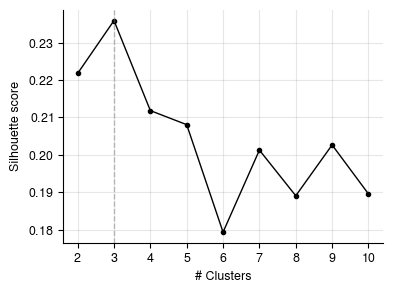

In [88]:
with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.plot(sens_k.index, sens_k["silhouette"], "o-", color="k")
    ax.axvline(3, linestyle="--", color="gray", alpha=0.5)
    ax.set_xlabel("# Clusters")
    ax.set_ylabel("Silhouette score")
    ax.set_xticks(range(2, 11))
    ax.grid(alpha=0.3)

    plt.savefig(FIG2_DIR / "silhouette_k.pdf", bbox_inches="tight")
    plt.savefig(FIG2_DIR / "silhouette_k.png", dpi=300, bbox_inches="tight")
    plt.show()

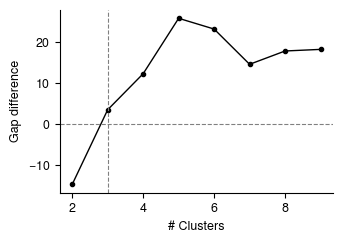

In [89]:
with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    ax.plot(sens_k.index, sens_k["gap_diff"], marker="o", color="k")
    ax.axhline(0, ls="--", color="grey", lw=0.8)
    ax.axvline(3, ls="--", color="grey", lw=0.8)
    ax.set_xlabel("# Clusters")
    ax.set_ylabel("Gap difference")
    plt.tight_layout()
    plt.savefig(FIG2_DIR / "gap_statistic.pdf", bbox_inches="tight")
    plt.savefig(FIG2_DIR / "gap_statistic.png", dpi=300, bbox_inches="tight")
    plt.show()

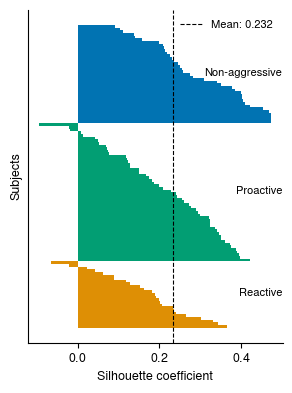

In [91]:
with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, ax = plt.subplots(figsize=(3, 4))

    sample_sils = silhouette_samples(Xa_scaled, res_kmeans3.consensus_a)
    y_lower = 0

    for c in range(k):
        cluster_sils = np.sort(sample_sils[res_kmeans3.consensus_a == c])[::-1]
        ax.barh(
            range(y_lower, y_lower + len(cluster_sils)),
            cluster_sils,
            height=1.0,
            color=palette[c],
            edgecolor="none",
        )
        ax.text(
            0.5,
            y_lower + len(cluster_sils) / 2,
            cluster_names[c],
            ha="right",
            va="center",
            fontsize=8,
        )
        y_lower += len(cluster_sils)

    ax.axvline(
        sample_sils.mean(),
        color="k",
        linestyle="--",
        linewidth=0.8,
        label=f"Mean: {sample_sils.mean():.3f}",
    )
    ax.set_xlabel("Silhouette coefficient")
    ax.set_ylabel("Subjects")
    ax.set_yticks([])
    ax.legend(fontsize=8)

    plt.savefig(FIG2_DIR / "silhouette_plot.pdf", bbox_inches="tight")
    plt.savefig(FIG2_DIR / "silhouette_plot.png", dpi=300, bbox_inches="tight")
    plt.show()

## Fig. 2c: Radar charts (per-cluster behavioural profiles)

In [40]:
minmax_scaler = MinMaxScaler()

Xa_minmax = minmax_scaler.fit_transform(
    Xa.drop(["PC1", "PC2", "Cluster", "label"], axis=1)
)

cluster_means_a = minmax_scaler.transform(
    Xa.drop(["PC1", "PC2", "label"], axis=1).groupby("Cluster").mean()
)

Xb_minmax = minmax_scaler.transform(Xb.drop(["PC1", "PC2", "Cluster", "label"], axis=1))

cluster_means_b = minmax_scaler.transform(
    Xb.drop(["PC1", "PC2", "label"], axis=1).groupby("Cluster").mean()
)

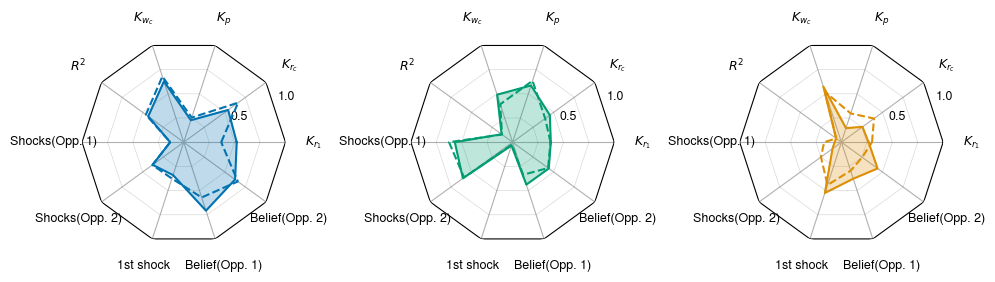

In [41]:
radar_labels = [
    r"$K_{r_1}$",
    r"$K_{r_c}$",
    r"$K_p$",
    r"$K_{w_c}$",
    r"$R^2$",
    "Shocks(Opp. 1)",
    "Shocks(Opp. 2)",
    "1st shock",
    "Belief(Opp. 1)",
    "Belief(Opp. 2)",
]

n_features = Xa_scaled.shape[1]
angles = np.linspace(0, 2 * np.pi, n_features, endpoint=False).tolist()
angles += angles[:1]

with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, axes = plt.subplots(1, 3, figsize=(10, 3.5), subplot_kw=dict(polar=True))

    for ax, cluster_id in zip(axes, [2, 1, 0]):
        values = cluster_means_a[cluster_id].tolist()
        values += values[:1]

        ax.fill(angles, values, alpha=0.25, color=palette[cluster_id], zorder=10)
        ax.plot(angles, values, color=palette[cluster_id], linewidth=1.5)

        values_b = cluster_means_b[cluster_id].tolist()
        values_b += values_b[:1]
        ax.plot(
            angles, values_b, color=palette[cluster_id], linewidth=1.5, linestyle="--"
        )

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(radar_labels)
        ax.set_ylim(0, 1)
        ax.set_yticks([0.25, 0.5, 0.75, 1.0])
        ax.set_yticklabels(["", "0.5", "", "1.0"])
        ax.yaxis.grid(False)
        ax.spines["polar"].set_visible(False)
        for r in [0.25, 0.5, 0.75, 1.0]:
            style = (
                {"color": "black", "linewidth": 0.8}
                if r == 1.0
                else {"color": "gray", "linewidth": 0.5, "alpha": 0.3}
            )
            ax.plot(angles, [r] * len(angles), **style)
        ax.tick_params(axis="x", pad=10)
    plt.tight_layout()
    plt.savefig(FIG2_DIR / "radar_charts.pdf", bbox_inches="tight")
    plt.savefig(FIG2_DIR / "radar_charts.png", dpi=300, bbox_inches="tight")
    plt.show()

### Supplementary Fig. 6

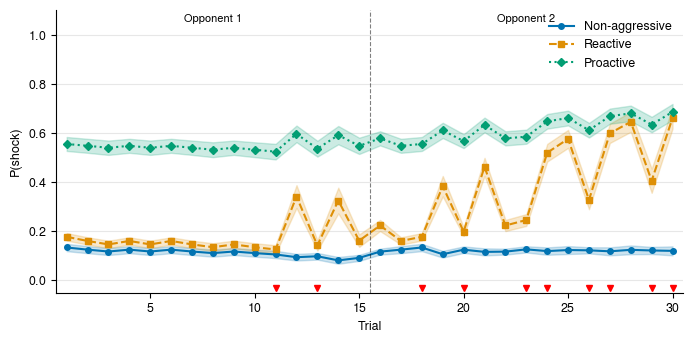

In [96]:
# Supplementary: Trial-by-trial P(shock) by cluster
pred = pd.read_csv("data/cohort_a/predictions.csv", header=None)
ids = pd.read_csv("data/cohort_a/subject_ids.csv")
pred.index = ids["subject"]

# Filter to clustered subjects
pred_cluster = pred.loc[Xa.index]
pred_cluster["Cluster"] = Xa["Cluster"].values

# Mean ± SEM per cluster per trial
cluster_means = pred_cluster.groupby("Cluster").mean()
cluster_sems = pred_cluster.groupby("Cluster").sem()

# Opponent shock schedule
script = pd.read_excel("data/shared/AggressionScript.xlsx", index_col="Session")
shocked = script.loc["Shocked"].values.astype(int)

cluster_hue_order = ["Non-aggressive", "Reactive", "Proactive"]

with plt.style.context(".matplotlib/paper.mplstyle"):
    cluster_colors = {cl["name"]: palette[cl["label"]] for cl in CLUSTERS}

    fig, ax = plt.subplots(figsize=(7, 3.5))

    x = np.arange(1, 31)
    markers = ["o", "s", "D"]
    linestyles = ["-", "--", ":"]

    for i, c in enumerate(cluster_hue_order):
        mean = cluster_means.loc[c].values
        sem = cluster_sems.loc[c].values
        color = cluster_colors[c]
        ax.fill_between(x, mean - sem, mean + sem, color=color, alpha=0.2)
        ax.plot(
            x,
            mean,
            color=color,
            marker=markers[i],
            linestyle=linestyles[i],
            label=c,
            markersize=4,
            linewidth=1.5,
        )

    # Mark opponent shocks
    for t in range(30):
        if shocked[t]:
            ax.plot(t + 1, -0.03, marker="v", color="red", markersize=4, clip_on=False)

    ax.axvline(x=15.5, color="k", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.text(8, 1.05, "Opponent 1", ha="center", fontsize=8)
    ax.text(23, 1.05, "Opponent 2", ha="center", fontsize=8)

    ax.set_xlabel("Trial")
    ax.set_ylabel("P(shock)")
    ax.set_ylim(-0.05, 1.1)
    ax.set_xlim(0.5, 30.5)
    ax.legend(title="", frameon=False)
    ax.set_axisbelow(True)
    ax.grid(alpha=0.3, axis="y", zorder=0)

    fig.tight_layout()
    fig.savefig(FIG2_DIR / "trial_pshock_by_cluster.pdf", bbox_inches="tight")
    fig.savefig(FIG2_DIR / "trial_pshock_by_cluster.png", dpi=300, bbox_inches="tight")
    plt.show()

### Supplementary Fig. 7

   opponent                      contrast      BF10  excl_zero
0         1  (Non-aggressive) - Proactive  0.316529      False
1         1   (Non-aggressive) - Reactive  0.603565      False
2         1          Proactive - Reactive  0.311913      False
3         2  (Non-aggressive) - Proactive  0.677694      False
4         2   (Non-aggressive) - Reactive  0.632417      False
5         2          Proactive - Reactive  0.118649      False


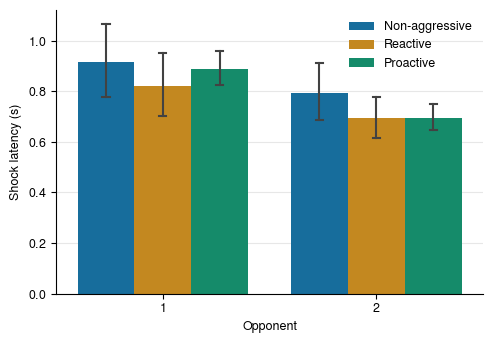

In [97]:
# Shock latency by cluster — posterior predicted means
latency_posterior = pd.read_csv("data/brms/latency/posterior_epred.csv").drop(
    columns=[".row", ".draw"], errors="ignore"
)
bf_latency = pd.read_csv("data/brms/latency/bayes_factors.csv")

print(bf_latency[["opponent", "contrast", "BF10", "excl_zero"]])

cluster_hue_order = ["Non-aggressive", "Reactive", "Proactive"]

cluster_colors = {cl["name"]: palette[cl["label"]] for cl in CLUSTERS}

with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, ax = plt.subplots(figsize=(5, 3.5))

    sns.barplot(
        data=latency_posterior,
        x="opponent",
        y="latency",
        hue="Cluster",
        hue_order=cluster_hue_order,
        palette=cluster_colors,
        errorbar=("pi", 95),
        capsize=0.1,
        ax=ax,
    )

    ax.set_xlabel("Opponent")
    ax.set_ylabel("Shock latency (s)")
    ax.legend(title="", frameon=False)
    ax.set_axisbelow(True)
    ax.grid(alpha=0.3, axis="y", zorder=0)

    fig.tight_layout()
    fig.savefig(FIG2_DIR / "shock_latency.pdf", bbox_inches="tight")
    fig.savefig(FIG2_DIR / "shock_latency.png", dpi=300, bbox_inches="tight")
    plt.show()

## Fig. 2d: Per-cluster shocks by opponent

In [11]:
# Melt shock_opp1 and shock_opp2 into long format
# Xa = pd.read_csv("data/processed/behav_Xa.csv", index_col=0)
Xa.index.name = "subject"
shock_long = (
    Xa[["shock_opp1", "shock_opp2", "label", "Cluster"]]
    .reset_index()
    .melt(
        id_vars=["subject", "label", "Cluster"],
        value_vars=["shock_opp1", "shock_opp2"],
        var_name="opponent",
        value_name="shocks",
    )
)
shock_long["opponent"] = shock_long["opponent"].map(
    {"shock_opp1": "Opponent 1", "shock_opp2": "Opponent 2"}
)

os.makedirs("data/processed", exist_ok=True)

# shock_long.to_csv("data/processed/shock_long.csv", index=False)

shock_long.head()

,subject,label,Cluster,opponent,shocks
0,P035,1,Proactive,Opponent 1,10.0
1,P036,1,Proactive,Opponent 1,8.0
2,P039,0,Reactive,Opponent 1,1.0
3,P042,1,Proactive,Opponent 1,2.0
4,P043,2,Non-aggressive,Opponent 1,0.0


In [3]:
shock_long_posterior = pd.read_csv("data/brms/shocks/posterior_epred.csv").drop(
    columns=[".row", ".draw"]
)
bf_shocks = pd.read_csv("data/brms/shocks/bayes_factors.csv")

In [13]:
def parse_contrast(c):
    """'(Non-aggressive) - Proactive' -> ('Non-aggressive', 'Proactive')"""
    parts = c.split(" - ")
    return parts[0].strip("() "), parts[1].strip("() ")


sig = bf_shocks[bf_shocks["excl_zero"]]

sig_contrasts_shocks = {}
for opp in bf_shocks["opponent"].unique():
    opp_sig = sig[sig["opponent"] == opp]
    sig_contrasts_shocks[opp] = []
    for _, row in opp_sig.iterrows():
        c1, c2 = parse_contrast(row["contrast"])
        bf = row["BF10"]
        label = "BF > 100" if bf > 100 else f"BF = {bf:.0f}"
        sig_contrasts_shocks[opp].append((c1, c2, label))

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Opponent 2_Non-aggressive vs. Opponent 2_Reactive: BF > 100
Opponent 2_Reactive vs. Opponent 2_Proactive: BF > 100
Opponent 1_Non-aggressive vs. Opponent 1_Reactive: BF = 6
Opponent 1_Reactive vs. Opponent 1_Proactive: BF > 100
Opponent 2_Non-aggressive vs. Opponent 2_Proactive: BF > 100
Opponent 1_Non-aggressive vs. Opponent 1_Proactive: BF > 100


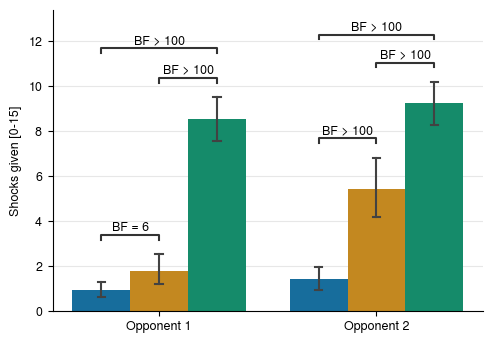

In [14]:
with plt.style.context(".matplotlib/paper.mplstyle"):
    palette = {
        "Non-aggressive": "#0173b2",
        "Proactive": "#029e73",
        "Reactive": "#de8f05"
    }

    fig, ax = plt.subplots(figsize=(5, 3.5))

    sns.barplot(
        data=shock_long_posterior,
        x="opponent",
        y="shocks",
        hue="Cluster",
        hue_order=["Non-aggressive", "Reactive", "Proactive"],
        palette=palette,
        errorbar=("pi", 95),
        capsize=0.1,
        ax=ax,
    )

    ax.set_xlabel("")
    ax.set_ylabel("Shocks given [0-15]")
    # ax.legend(title="")
    ax.legend().remove()
    ax.set_axisbelow(True)
    ax.grid(alpha=0.3, axis="y", zorder=0)
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

    pairs = []
    custom_annots = []
    for opp in sig_contrasts_shocks:
        for c1, c2, bf_label in sig_contrasts_shocks[opp]:
            pairs.append(((opp, c1), (opp, c2)))
            custom_annots.append(bf_label)

    if pairs:
        annot = Annotator(
            ax,
            pairs,
            data=shock_long_posterior,
            x="opponent",
            y="shocks",
            hue="Cluster",
            hue_order=["Non-aggressive", "Reactive", "Proactive"],
        )
        annot.set_custom_annotations(custom_annots)
        annot.annotate()

    plt.savefig(FIG2_DIR / "shocks_by_opponent.pdf", bbox_inches="tight")
    plt.savefig(FIG2_DIR / "shocks_by_opponent.png", dpi=300, bbox_inches="tight")
    plt.show()

### Supplementary Table 4

In [4]:
print(bf_shocks.set_index("contrast").round(3).to_markdown())

| contrast                     | opponent   |   estimate |   Q2.5 |   Q97.5 |            BF10 | excl_zero   |
|:-----------------------------|:-----------|-----------:|-------:|--------:|----------------:|:------------|
| (Non-aggressive) - Proactive | Opponent 1 |     -3.014 | -3.493 |  -2.557 |     6.00927e+12 | True        |
| (Non-aggressive) - Reactive  | Opponent 1 |     -0.721 | -1.288 |  -0.155 |     6.264       | True        |
| Proactive - Reactive         | Opponent 1 |      2.296 |  1.799 |   2.798 |     3.64558e+08 | True        |
| (Non-aggressive) - Proactive | Opponent 2 |     -2.745 | -3.227 |  -2.287 |     1.29513e+12 | True        |
| (Non-aggressive) - Reactive  | Opponent 2 |     -1.707 | -2.247 |  -1.18  | 82389.8         | True        |
| Proactive - Reactive         | Opponent 2 |      1.043 |  0.572 |   1.515 |   200.247       | True        |


## Fig. 2e: PSAP concurrent validity

In [54]:
# Load PSAP data and merge with Bravura clusters
psap = pd.read_excel("data/raw/additional.xlsx")
psap = psap.set_index("Subject")

# Merge with Bravura cluster labels (Xa index = subject IDs)
psap_cluster = psap[["pA", "pB", "pC", "rA", "rB", "rC"]].join(
    Xa[["label", "Cluster"]], how="inner"
)
psap_cluster = psap_cluster.dropna()

psap_dir = psap_cluster.reset_index()
psap_pro = psap_dir[["Subject", "label", "Cluster", "pA", "pB", "pC"]].copy()
psap_pro.columns = ["Subject", "label", "Cluster", "Earn", "Steal", "Protect"]
psap_pro["phase"] = "Proactive"

psap_rea = psap_dir[["Subject", "label", "Cluster", "rA", "rB", "rC"]].copy()
psap_rea.columns = ["Subject", "label", "Cluster", "Earn", "Steal", "Protect"]
psap_rea["phase"] = "Reactive"

# Combine phases
psap_comp = pd.concat([psap_pro, psap_rea], ignore_index=True)

# Replace zeros and ones with noise, then renormalize
rng = np.random.default_rng(RANDOM_SEED)
buttons = ["Earn", "Steal", "Protect"]

for i, row in psap_comp.iterrows():
    vals = row[buttons].values.astype(float)
    # Replace zeros with N(0.01, 0.0025), clipped to (0, min_real_nonzero)
    zero_mask = vals == 0
    ones_mask = vals == 1.0
    n_zeros = zero_mask.sum()
    if n_zeros > 0:
        noise = rng.normal(0.01, 0.0025, size=n_zeros).clip(1e-6, 0.025)
        vals[zero_mask] = noise
    if ones_mask.any():
        vals[ones_mask] = 1.0  # will be adjusted by renormalization
    # Renormalize so row sums to 1
    vals = vals / vals.sum()
    psap_comp.loc[i, buttons] = vals

psap_comp.to_csv("data/processed/psap_ilr.csv", index=False)
psap_comp.head()

,Subject,label,Cluster,Earn,Steal,Protect,phase
0,P035,1,Proactive,0.333333,0.333333,0.333333,Proactive
1,P036,1,Proactive,0.571429,0.142857,0.285714,Proactive
2,P039,0,Reactive,0.200000,0.333333,0.466667,Proactive
3,P042,1,Proactive,0.230769,0.461538,0.307692,Proactive
4,P043,2,Non-aggressive,0.395741,0.010647,0.593612,Proactive


In [56]:
posterior_psap = pd.read_csv("data/brms/psap/posterior_epred.csv")
bf_table = pd.read_csv("data/brms/psap/bayes_factors.csv")

In [58]:
def get_bf(phase, button, c1, c2):
    row = bf_table[
        (bf_table["phase"] == phase)
        & (bf_table["button"] == button)
        & (bf_table["contrast"] == f"{c1} - {c2}")
    ]
    return row["BF10"].values[0]


# Significant contrasts per phase
sig = bf_table[bf_table["excl_zero"]]

sig_contrasts = {}
for phase in ["Proactive", "Reactive"]:
    phase_sig = sig[sig["phase"] == phase]
    sig_contrasts[phase] = [
        (
            row["button"],
            row["contrast"].split(" - ")[0],
            row["contrast"].split(" - ")[1],
            "*",
        )
        for _, row in phase_sig.iterrows()
    ]

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Protect_Non-aggressive vs. Protect_Reactive: *
Steal_Non-aggressive vs. Steal_Proactive: *
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Steal_Non-aggressive vs. Steal_Reactive: *
Steal_Non-aggressive vs. Steal_Proactive: *


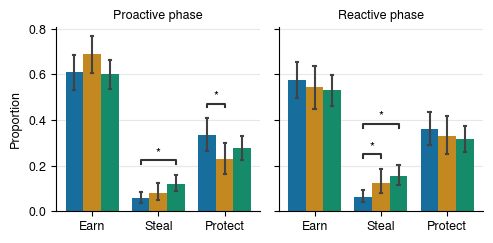

In [59]:
name_palette = {
    "Non-aggressive": "#0173b2",
    "Reactive": "#de8f05",
    "Proactive": "#029e73",
}

with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, axes = plt.subplots(1, 2, figsize=(5, 2.5), sharey=True)

    for ax, phase in zip(axes, ["Proactive", "Reactive"]):
        phase_data = posterior_psap[posterior_psap["phase"] == phase]
        sns.barplot(
            data=phase_data,
            x="button",
            y="proportion",
            hue="Cluster",
            hue_order=["Non-aggressive", "Reactive", "Proactive"],
            order=["Earn", "Steal", "Protect"],
            palette=name_palette,
            errorbar=("pi", 95),
            capsize=0.1,
            ax=ax,
        )
        ax.set_title(f"{phase} phase")
        ax.set_xlabel("")
        ax.set_axisbelow(True)
        ax.grid(alpha=0.3, axis="y", zorder=0)
        ax.get_legend().remove()

        pairs = []
        custom_annots = []
        for button, c1, c2, bf_label in sig_contrasts.get(phase, []):
            pairs.append(((button, c1), (button, c2)))
            custom_annots.append(bf_label)

        if pairs:
            annot = Annotator(
                ax,
                pairs,
                data=phase_data,
                x="button",
                y="proportion",
                hue="Cluster",
                hue_order=["Non-aggressive", "Reactive", "Proactive"],
                order=["Earn", "Steal", "Protect"],
            )
            annot.set_custom_annotations(custom_annots)
            annot.annotate()

    axes[0].set_ylabel("Proportion")
    # axes[-1].legend(title="", bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.savefig(FIG2_DIR / "psap_concurrent.pdf", bbox_inches="tight")
    plt.savefig(FIG2_DIR / "psap_concurrent.png", dpi=300, bbox_inches="tight")
    plt.show()

### Supplementary Table 5

In [57]:
print(bf_table.set_index("contrast").round(3).to_markdown())

| contrast                   | phase     | button   |   mean_diff |   Q2.5 |   Q97.5 |   BF10 | excl_zero   |
|:---------------------------|:----------|:---------|------------:|-------:|--------:|-------:|:------------|
| Proactive - Non-aggressive | Proactive | Earn     |      -0.008 | -0.107 |   0.091 |    1.3 | False       |
| Reactive - Non-aggressive  | Proactive | Earn     |       0.081 | -0.03  |   0.191 |   11.8 | False       |
| Proactive - Reactive       | Proactive | Earn     |      -0.089 | -0.189 |   0.018 |   18.2 | False       |
| Proactive - Non-aggressive | Proactive | Steal    |       0.064 |  0.022 |   0.107 |  999   | True        |
| Reactive - Non-aggressive  | Proactive | Steal    |       0.025 | -0.017 |   0.073 |    6.8 | False       |
| Proactive - Reactive       | Proactive | Steal    |       0.039 | -0.015 |   0.09  |   12.8 | False       |
| Proactive - Non-aggressive | Proactive | Protect  |      -0.056 | -0.145 |   0.031 |    8.1 | False       |
| Reactive

### Supplementary Fig. 8

ARI = 0.024
PSAP             0   1   2
Bravura                   
Non-aggressive   3  14  19
Proactive       19  16  16
Reactive         8  10   7


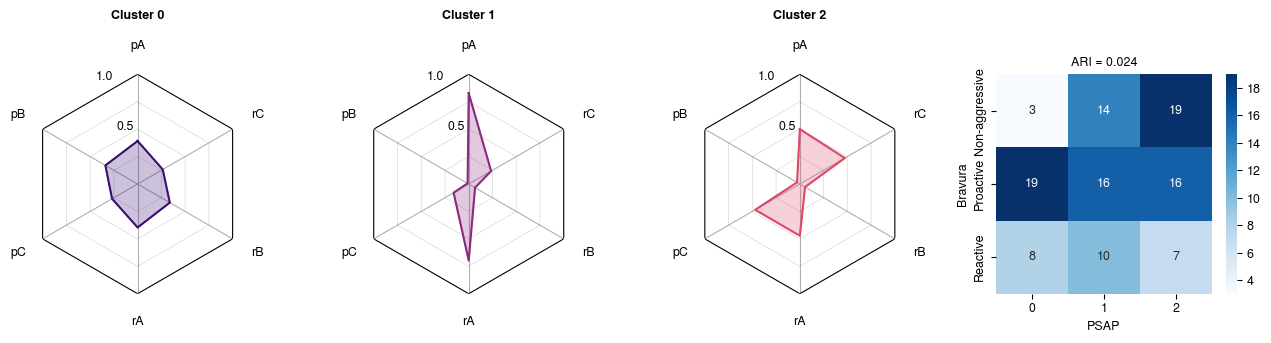

In [98]:
# PSAP clustering
psap_features = ["pA", "pB", "pC", "rA", "rB", "rC"]
psap_clust = psap_dir[["Subject", "Cluster"] + psap_features].dropna()

X_psap = (
    psap_clust[psap_features]
    .sub(psap_clust[psap_features].mean())
    .div(psap_clust[psap_features].std())
)
res_psap = fit_predict(X_psap.values, solver="k-means", k=3, random_state=RANDOM_SEED)
psap_clust["psap_cluster"] = res_psap.labels

# ARI: Bravura clusters vs PSAP clusters
ari = adjusted_rand_score(psap_clust["Cluster"], psap_clust["psap_cluster"])
print(f"ARI = {ari:.3f}")

# Contingency table
ct = pd.crosstab(
    psap_clust["Cluster"],
    psap_clust["psap_cluster"],
    rownames=["Bravura"],
    colnames=["PSAP"],
)
print(ct)

# PSAP cluster profiles (mean proportions per cluster)
psap_radar_labels = ["pA", "pB", "pC", "rA", "rB", "rC"]
psap_profiles = psap_clust.groupby("psap_cluster")[psap_features].mean()
psap_palette = sns.color_palette("magma", 4)[:-1]  # 3 colors from magma

n_feat = len(psap_features)
angles = np.linspace(0, 2 * np.pi, n_feat, endpoint=False).tolist()
angles += angles[:1]

with plt.style.context(".matplotlib/paper.mplstyle"):
    fig = plt.figure(figsize=(13, 3.5))

    for i, cluster_id in enumerate(sorted(psap_profiles.index)):
        ax = fig.add_subplot(1, 4, i + 1, projection="polar")
        ax.set_theta_offset(np.pi / 2)

        values = psap_profiles.loc[cluster_id].tolist()
        values += values[:1]

        ax.fill(angles, values, alpha=0.25, color=psap_palette[cluster_id], zorder=10)
        ax.plot(angles, values, color=psap_palette[cluster_id], linewidth=1.5)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(psap_radar_labels)
        ax.set_ylim(0, 1)
        ax.set_yticks([0.25, 0.5, 0.75, 1.0])
        ax.set_yticklabels(["", "0.5", "", "1.0"])
        ax.yaxis.grid(False)
        ax.spines["polar"].set_visible(False)
        for r in [0.25, 0.5, 0.75, 1.0]:
            style = (
                {"color": "black", "linewidth": 0.8}
                if r == 1.0
                else {"color": "gray", "linewidth": 0.5, "alpha": 0.3}
            )
            ax.plot(angles, [r] * len(angles), **style)
        ax.tick_params(axis="x", pad=10)
        ax.set_title(f"Cluster {cluster_id}", pad=15, fontweight="bold")

    ax_ct = fig.add_subplot(1, 4, 4)
    sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", ax=ax_ct)
    ax_ct.set_title(f"ARI = {ari:.3f}")

    plt.tight_layout()
    plt.savefig(FIG2_DIR / "psap_clustering.pdf", bbox_inches="tight")
    plt.savefig(FIG2_DIR / "psap_clustering.png", dpi=300, bbox_inches="tight")
    plt.show()

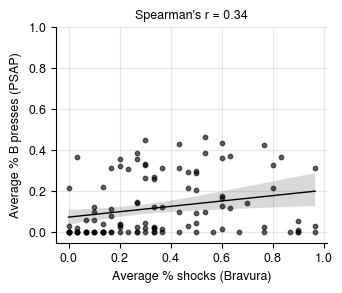

In [93]:
# Scatter: total Bravura shocks vs PSAP B-presses
psap_scatter = psap_dir[["Subject", "Cluster"]].drop_duplicates()
psap_scatter = psap_scatter.merge(
    psap[["NumShocks", "pB", "rB"]],
    left_on="Subject",
    right_index=True,
)
psap_scatter["B_prop"] = (psap_scatter["pB"] + psap_scatter["rB"]) / 2
psap_scatter = psap_scatter.dropna()
psap_scatter["shock_prop"] = psap_scatter["NumShocks"] / 30
r = psap_scatter["shock_prop"].corr(psap_scatter["B_prop"], method="spearman")

with plt.style.context(".matplotlib/paper.mplstyle"):
    fig, ax = plt.subplots(figsize=(3.5, 3))
    sns.regplot(
        data=psap_scatter,
        x="shock_prop",
        y="B_prop",
        scatter_kws={"s": 10, "alpha": 0.6},
        color="k",
        line_kws={"lw": 1},
        ax=ax,
    )
    ax.set_xlabel("Average % shocks (Bravura)")
    ax.set_ylabel("Average % B presses (PSAP)")
    ax.set_ylim(-0.05, 1)
    ax.set_title(f"Spearman's r = {r:.2f}")
    # ax.legend([f"Spearman's $r$ = {r:.2f}"], loc="upper left", frameon=True)
    ax.set_axisbelow(True)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG2_DIR / "bravura_psap_scatter.pdf", bbox_inches="tight")
    plt.savefig(FIG2_DIR / "bravura_psap_scatter.png", dpi=300, bbox_inches="tight")
    plt.show()